# Deepfake Detection in the Wild

## Complete end-to-end project notebook

**Course:** UTS 42177 Image Processing and Pattern Recognition  
**Task:** Classify aligned face images as real (`0`) or fake (`1`)  
**Primary dataset:** FaceForensics++ c23  
**Main experiments:** cross-generation generalisation and JPEG robustness

This notebook is the single entry point for the project. It brings together
dataset inspection, preprocessing commands, leakage-safe splitting, model
construction, training, evaluation, ensembling, compression testing,
cross-generation testing, Grad-CAM outputs and the final conclusions.

The tested implementation remains organised in the `src` package so that the
same code is shared by this notebook, automated tests and cloud training. The
notebook calls those Python functions directly wherever practical and provides
controlled wrappers for long-running data preparation commands.

## How to use this notebook safely

The notebook opens in **results/review mode**. Existing manifests, checkpoints
and result tables are loaded, but dataset downloads, face extraction, model
training and expensive re-evaluation are disabled.

To reproduce a stage, change its corresponding `RUN_*` flag below and execute
that section. Do not enable dataset download unless FaceForensics++ access has
already been approved. Full training is intended for an NVIDIA GPU and can take
considerable time.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, Markdown, display

# Work whether Jupyter starts in the repository root or in notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir():
    raise RuntimeError("Open this notebook from the deepfake-detection repository")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config
from src.data.splits import split_manifest
from src.eval.ensemble import combine_predictions, detailed_report, optimise_two_model_weight
from src.eval.metrics import find_optimal_threshold, report_all
from src.evaluate import evaluate_checkpoint
from src.models import build_model
from src.train import train
from src.utils import resolve_device, seed_everything

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Project root: C:\Users\Rohith Syam\Documents\UTS SEMESTER 3\image processing\idea 2
Python: 3.11.9
PyTorch: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# Safety controls: expensive or external operations remain off by default.
RUN_DOWNLOAD = False
RUN_PREPROCESSING = False
RUN_SPLITTING = False
RUN_MODEL_INSPECTION = False
RUN_TRAINING = False
RUN_EXPENSIVE_EVALUATION = False
RUN_TSNE = False
RUN_GRADCAM = False

MODEL_TO_TRAIN = "hybrid"       # meso, freq_cnn, xception, or hybrid
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
seed_everything(SEED)

DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
SPLIT_ROOT = DATA_ROOT / "splits_200video"

CHECKPOINTS = {
    "hybrid": OUTPUT_ROOT / "modal_downloads" / "hybrid_200video_full_best.pt",
    "xception": OUTPUT_ROOT / "modal_downloads" / "xception_200video_full_best.pt",
}

print("Mode: safe review" if not any([
    RUN_DOWNLOAD, RUN_PREPROCESSING, RUN_SPLITTING, RUN_TRAINING,
    RUN_EXPENSIVE_EVALUATION, RUN_TSNE, RUN_GRADCAM
]) else "Mode: one or more active reproduction stages")

Mode: safe review


## 1. Research design

The detector is trained on GAN-era and graphics-based FaceForensics++
manipulations—Deepfakes, Face2Face, FaceSwap and NeuralTextures. It is then
tested in three ways:

1. **In-domain:** held-out FaceForensics++ identities.
2. **Compression robustness:** JPEG qualities 100, 90, 60, 40, 20 and 10.
3. **Cross-generation:** paired real and Stable Diffusion v1.5 faces.

This design tests whether high performance on familiar manipulations is a
reliable indication of real-world generalisation.

## 2. Dataset audit

The final FaceForensics++ sample contains 1,000 videos and 30,000 aligned face
crops. Splits are grouped by target identity so that a pristine source and all
of its manipulations cannot appear in different partitions.

In [3]:
def audit_manifest(path: Path) -> dict:
    frame = pd.read_csv(path)
    required = {"image_path", "label", "video_id", "method", "dataset"}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{path} is missing {sorted(missing)}")
    return {
        "split": path.stem,
        "images": len(frame),
        "identity_groups": frame["video_id"].astype(str).nunique(),
        "real_images": int((frame["label"] == 0).sum()),
        "fake_images": int((frame["label"] == 1).sum()),
        "methods": ", ".join(sorted(frame["method"].astype(str).unique())),
    }

split_paths = [SPLIT_ROOT / f"{name}.csv" for name in ("train", "val", "test")]
if all(path.is_file() for path in split_paths):
    split_audit = pd.DataFrame([audit_manifest(path) for path in split_paths])
    display(split_audit)
    all_groups = {
        path.stem: set(pd.read_csv(path)["video_id"].astype(str)) for path in split_paths
    }
    assert all_groups["train"].isdisjoint(all_groups["val"])
    assert all_groups["train"].isdisjoint(all_groups["test"])
    assert all_groups["val"].isdisjoint(all_groups["test"])
    print("Identity leakage check: PASSED")
else:
    print("Final split manifests are not available in this environment.")

,split,images,identity_groups,real_images,fake_images,methods
0,train,21000,140,4200,16800,"Deepfakes, Face2Face, FaceSwap, NeuralTextures..."
1,val,4500,30,900,3600,"Deepfakes, Face2Face, FaceSwap, NeuralTextures..."
2,test,4500,30,900,3600,"Deepfakes, Face2Face, FaceSwap, NeuralTextures..."


Identity leakage check: PASSED


### Visual check of processed crops

This is an image-processing quality-control step. It verifies that the saved
inputs contain centred faces rather than full frames, blank images or failed
detections.

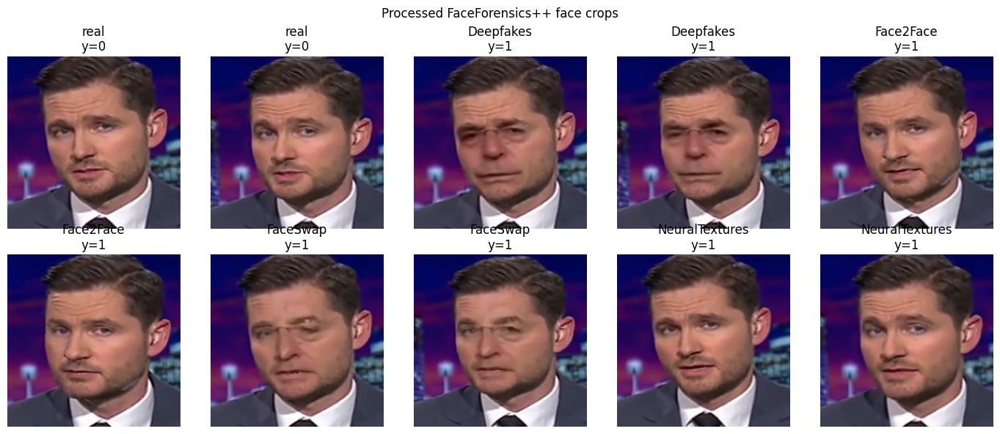

In [4]:
test_manifest = SPLIT_ROOT / "test.csv"
if test_manifest.is_file():
    test_frame = pd.read_csv(test_manifest)
    samples = (
        test_frame.groupby("method", group_keys=False)
        .head(2)
        .head(10)
        .reset_index(drop=True)
    )
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for axis, (_, row) in zip(axes.flat, samples.iterrows()):
        path = Path(row.image_path)
        if not path.is_absolute():
            path = DATA_ROOT / path
        image_bgr = cv2.imread(str(path))
        if image_bgr is None:
            axis.text(0.5, 0.5, "missing", ha="center", va="center")
        else:
            axis.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
        axis.set_title(f"{row.method}\ny={row.label}")
        axis.axis("off")
    for axis in axes.flat[len(samples):]:
        axis.axis("off")
    fig.suptitle("Processed FaceForensics++ face crops")
    fig.tight_layout()
    plt.show()

## 3. Optional dataset download

FaceForensics++ requires approval and acceptance of its research licence. The
official downloader placed in the repository can be controlled from this
notebook. The example downloads the first 200 c23 videos for each required
category. Keep `RUN_DOWNLOAD=False` when reviewing existing results.

In [5]:
if RUN_DOWNLOAD:
    downloader = PROJECT_ROOT / "face_forensics_Script.py"
    destination = DATA_ROOT / "raw" / "faceforensics"
    for dataset_name in ["original", "Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]:
        command = [
            sys.executable, str(downloader), str(destination),
            "--dataset", dataset_name,
            "--compression", "c23",
            "--type", "videos",
            "--num_videos", "200",
        ]
        print("Running:", " ".join(command))
        subprocess.run(command, check=True)
else:
    print("Download skipped. Set RUN_DOWNLOAD=True only after access approval.")

Download skipped. Set RUN_DOWNLOAD=True only after access approval.


## 4. Face extraction and preprocessing

For each video, 30 frames are sampled uniformly. MTCNN detects the dominant
face, after which a margin is added and the crop is aligned and resized.
Training augmentation adds flips, rotations, colour variation and random JPEG
compression. The project command is invoked from this notebook so all stages
can be controlled in one place.

In [6]:
def prepare_video_category(
    input_dir: Path,
    output_dir: Path,
    manifest: Path,
    label: int,
    method: str,
    device: str = DEVICE,
) -> None:
    command = [
        sys.executable, "-m", "src.data.prepare_videos",
        "--input", str(input_dir),
        "--output", str(output_dir),
        "--manifest", str(manifest),
        "--label", str(label),
        "--method", method,
        "--dataset", "faceforensics",
        "--device", device,
        "--num-frames", "30",
        "--detection-batch-size", "4",
        "--skip-existing",
    ]
    print("Running:", " ".join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

if RUN_PREPROCESSING:
    raw_root = DATA_ROOT / "raw" / "faceforensics"
    processed_root = DATA_ROOT / "processed" / "faceforensics"
    specifications = [
        ("original_sequences/youtube/c23/videos", "real", 0, "real"),
        ("manipulated_sequences/Deepfakes/c23/videos", "Deepfakes", 1, "Deepfakes"),
        ("manipulated_sequences/Face2Face/c23/videos", "Face2Face", 1, "Face2Face"),
        ("manipulated_sequences/FaceSwap/c23/videos", "FaceSwap", 1, "FaceSwap"),
        ("manipulated_sequences/NeuralTextures/c23/videos", "NeuralTextures", 1, "NeuralTextures"),
    ]
    for relative_input, folder, label, method in specifications:
        prepare_video_category(
            raw_root / relative_input,
            processed_root / folder,
            DATA_ROOT / "manifests" / f"{folder}.csv",
            label,
            method,
        )
else:
    print("Face extraction skipped; existing processed crops will be used.")

Face extraction skipped; existing processed crops will be used.


## 5. Combine manifests and create identity-safe splits

The split function uses grouped sampling. The group key is the target identity,
not the individual crop, so related real and manipulated content stays in one
partition.

In [7]:
if RUN_SPLITTING:
    manifest_paths = sorted((DATA_ROOT / "manifests").glob("*.csv"))
    if not manifest_paths:
        raise FileNotFoundError("No category manifests were found")
    combined = pd.concat([pd.read_csv(path) for path in manifest_paths], ignore_index=True)
    combined_path = DATA_ROOT / "faceforensics_manifest_notebook.csv"
    combined.to_csv(combined_path, index=False)

    partitions = split_manifest(combined, seed=SEED)
    notebook_split_root = DATA_ROOT / "splits_notebook"
    notebook_split_root.mkdir(parents=True, exist_ok=True)
    for name, part in partitions.items():
        part.to_csv(notebook_split_root / f"{name}.csv", index=False)
        print(name, len(part), "images", part.video_id.nunique(), "groups")
else:
    print("Split creation skipped; using data/splits_200video.")

Split creation skipped; using data/splits_200video.


## 6. Models

Four approaches are included:

- **MesoInception:** compact spatial CNN baseline;
- **Xception:** ImageNet-pretrained depthwise-separable CNN;
- **Frequency CNN:** dual-domain model using RGB and spectral evidence;
- **CoAtNet hybrid:** convolution plus attention, used as the strongest model.

The model registry ensures training, evaluation and Grad-CAM load exactly the
same architecture definitions.

In [8]:
if RUN_MODEL_INSPECTION:
    model_rows = []
    for model_name in ("meso", "freq_cnn", "xception", "hybrid"):
        model = build_model(model_name, num_classes=1, pretrained=False)
        parameters = sum(parameter.numel() for parameter in model.parameters())
        trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
        model_rows.append({"model": model_name, "parameters": parameters, "trainable": trainable})
        del model
    display(pd.DataFrame(model_rows))
else:
    print("Model construction skipped. Set RUN_MODEL_INSPECTION=True to inspect architectures.")

Model construction skipped. Set RUN_MODEL_INSPECTION=True to inspect architectures.


## 7. Training

Training uses balanced sampling, binary cross-entropy, AdamW, cosine decay,
mixed precision, transfer-backbone freezing and validation-AUC checkpoint
selection. Classification thresholds are selected on validation balanced
accuracy. The held-out test set is never used for model selection.

In [9]:
CONFIG_PATHS = {
    "meso": PROJECT_ROOT / "config" / "meso.yaml",
    "freq_cnn": PROJECT_ROOT / "config" / "freq_cnn.yaml",
    "xception": PROJECT_ROOT / "config" / "xception_200video.yaml",
    "hybrid": PROJECT_ROOT / "config" / "hybrid_200video.yaml",
}

if RUN_TRAINING:
    training_config = load_config(CONFIG_PATHS[MODEL_TO_TRAIN])
    training_config["device"] = DEVICE
    training_config["data"].update({
        "root": str(DATA_ROOT),
        "train_csv": str(SPLIT_ROOT / "train.csv"),
        "val_csv": str(SPLIT_ROOT / "val.csv"),
        "test_csv": str(SPLIT_ROOT / "test.csv"),
        "num_workers": 0 if os.name == "nt" else 4,
    })
    training_config["logging"]["output_dir"] = str(
        OUTPUT_ROOT / "notebook_runs" / MODEL_TO_TRAIN
    )
    print(json.dumps(training_config, indent=2))
    trained_checkpoint = train(training_config)
    print("Best checkpoint:", trained_checkpoint)
else:
    print("Training skipped. Existing final checkpoints will be analysed.")

Training skipped. Existing final checkpoints will be analysed.


## 8. Optional checkpoint re-evaluation

This cell reproduces full predictions for the final hybrid and Xception
checkpoints. It is disabled because the saved outputs below already contain the
held-out results.

In [10]:
if RUN_EXPENSIVE_EVALUATION:
    for model_name, checkpoint in CHECKPOINTS.items():
        if not checkpoint.is_file():
            print("Missing checkpoint:", checkpoint)
            continue
        result, predictions = evaluate_checkpoint(
            checkpoint,
            SPLIT_ROOT / "test.csv",
            DATA_ROOT,
            DEVICE,
            64 if model_name == "hybrid" else 32,
            0,
        )
        destination = OUTPUT_ROOT / "notebook_runs" / f"{model_name}_test_predictions.csv"
        destination.parent.mkdir(parents=True, exist_ok=True)
        predictions.to_csv(destination, index=False)
        print(model_name, result["metrics"])
else:
    print("Full inference skipped; loading verified saved result tables.")

Full inference skipped; loading verified saved result tables.


## 9. Final held-out results

In [11]:
summary_path = OUTPUT_ROOT / "tables" / "model_summary_200video_cloud.csv"
if summary_path.is_file():
    final_summary = pd.read_csv(summary_path)
    columns = [
        "model", "frame_auc", "frame_accuracy", "frame_balanced_accuracy",
        "precision", "recall", "f1", "video_auc", "cross_generation_auc",
        "jpeg_q10_auc",
    ]
    display(final_summary[[column for column in columns if column in final_summary]])
else:
    print("Final summary table not found.")

,model,frame_auc,frame_accuracy,frame_balanced_accuracy,precision,recall,f1,video_auc,cross_generation_auc,jpeg_q10_auc
0,hybrid,0.883282,0.793111,0.784028,0.932577,0.799167,0.860733,0.903889,0.385694,0.712465
1,xception,0.861681,0.758889,0.775139,0.938001,0.748056,0.832329,0.895833,0.389878,0.660765
2,hybrid_xception_ensemble,0.880519,0.771556,0.784722,0.940411,0.762778,0.842331,0.903889,0.382318,NaN


### Interpretation

The CoAtNet hybrid is the strongest single-frame model with test AUC **0.8833**
and F1 **0.8607**. Its precision of **0.9326** shows that fake predictions are
usually reliable, although its conservative threshold reduces recall to
**0.7992**. Frame aggregation increases hybrid video AUC to **0.9039**.

The video-calibrated hybrid/Xception ensemble reaches video AUC **0.9047**,
balanced accuracy **0.8250** and F1 **0.8947**, making it the preferred whole-
video configuration. Ensembling does not improve the hybrid's frame AUC,
indicating correlated frame-level errors.

## 10. Per-manipulation analysis

,model,method,auc,accuracy,balanced_accuracy,precision,recall,specificity,f1
0,hybrid,Deepfakes,0.913944,0.807778,0.807778,0.785567,0.846667,0.768889,0.814973
1,hybrid,Face2Face,0.902177,0.803889,0.803889,0.784008,0.838889,0.768889,0.810521
2,hybrid,FaceSwap,0.893241,0.802222,0.802222,0.783333,0.835556,0.768889,0.808602
3,hybrid,NeuralTextures,0.823767,0.722222,0.722222,0.745098,0.675556,0.768889,0.708625
4,xception,Deepfakes,0.893677,0.821667,0.821667,0.809626,0.841111,0.802222,0.825068
5,xception,Face2Face,0.880262,0.780556,0.780556,0.793264,0.758889,0.802222,0.775696
6,xception,FaceSwap,0.847456,0.762778,0.762778,0.785283,0.723333,0.802222,0.753036
7,xception,NeuralTextures,0.825328,0.735556,0.735556,0.771795,0.668889,0.802222,0.716667


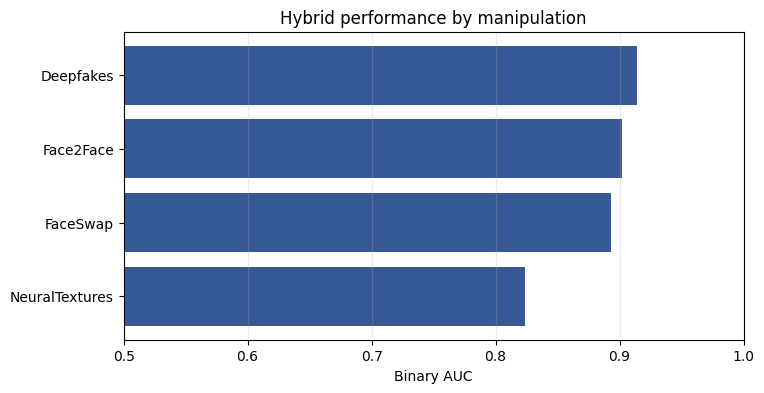

In [12]:
per_method_path = OUTPUT_ROOT / "tables" / "per_method_summary_200video_cloud.csv"
if per_method_path.is_file():
    per_method = pd.read_csv(per_method_path)
    display(per_method)

    hybrid_methods = per_method[per_method.model == "hybrid"].sort_values("auc")
    fig, axis = plt.subplots(figsize=(8, 4))
    axis.barh(hybrid_methods.method, hybrid_methods.auc, color="#345995")
    axis.set(xlim=(0.5, 1.0), xlabel="Binary AUC", title="Hybrid performance by manipulation")
    axis.grid(axis="x", alpha=0.25)
    plt.show()

Deepfakes is easiest for the hybrid (AUC **0.9139**), followed by Face2Face
and FaceSwap. NeuralTextures is hardest (AUC **0.8238**), showing that model
performance depends on the manipulation process.

## 11. JPEG compression robustness

,model,quality,auc,accuracy,balanced_accuracy,f1
0,hybrid,100,0.883282,0.793111,0.784028,0.860733
1,hybrid,90,0.863583,0.773333,0.762083,0.846432
2,hybrid,60,0.844442,0.734444,0.750278,0.813485
3,hybrid,40,0.826758,0.706667,0.737500,0.789137
4,hybrid,20,0.776293,0.603556,0.685556,0.688982
5,hybrid,10,0.712465,0.337333,0.572917,0.303271
6,xception,100,0.861669,0.758889,0.775139,0.832329
7,xception,90,0.850459,0.739333,0.762083,0.816346
8,xception,60,0.826096,0.694444,0.737778,0.777039
9,xception,40,0.800963,0.658000,0.714583,0.743714


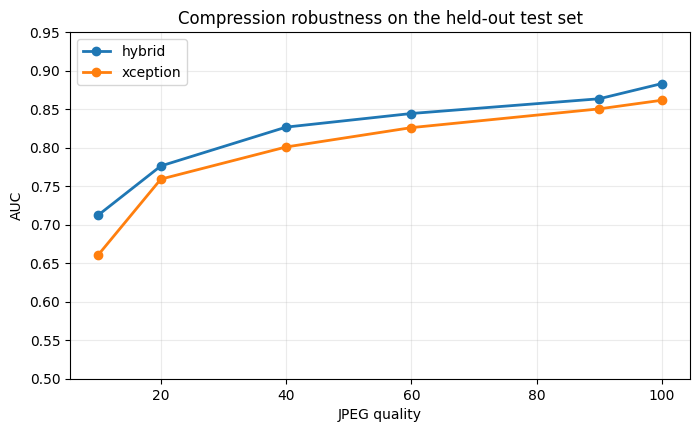

In [13]:
compression_path = OUTPUT_ROOT / "tables" / "compression_200video_cloud.csv"
if compression_path.is_file():
    compression = pd.read_csv(compression_path)
    display(compression[["model", "quality", "auc", "accuracy", "balanced_accuracy", "f1"]])

    fig, axis = plt.subplots(figsize=(8, 4.5))
    for model_name, rows in compression.groupby("model"):
        rows = rows.sort_values("quality")
        axis.plot(rows.quality, rows.auc, marker="o", linewidth=2, label=model_name)
    axis.set(
        xlabel="JPEG quality",
        ylabel="AUC",
        ylim=(0.5, 0.95),
        title="Compression robustness on the held-out test set",
    )
    axis.grid(alpha=0.25)
    axis.legend()
    plt.show()

Hybrid AUC falls from **0.8833 at Q100** to **0.7125 at Q10**. Xception falls
from **0.8617** to **0.6608**. Compression removes or alters subtle forensic
signals, although the hybrid remains stronger at every quality level.

## 12. Cross-generation evaluation

In [14]:
cross_rows = []
for model_name in ("hybrid", "xception"):
    path = OUTPUT_ROOT / "tables" / f"{model_name}_200video_cloud_deepfakeface.json"
    in_domain_path = OUTPUT_ROOT / "modal_downloads" / f"{model_name}_test.json"
    if path.is_file() and in_domain_path.is_file():
        cross = json.loads(path.read_text(encoding="utf-8"))
        in_domain = json.loads(in_domain_path.read_text(encoding="utf-8"))
        in_auc = float(in_domain["metrics"]["auc"])
        cross_auc = float(cross["metrics"]["auc"])
        cross_rows.append({
            "model": model_name,
            "FaceForensics++ AUC": in_auc,
            "Stable Diffusion AUC": cross_auc,
            "AUC drop": in_auc - cross_auc,
        })

if cross_rows:
    cross_generation = pd.DataFrame(cross_rows)
    display(cross_generation)

,model,FaceForensics++ AUC,Stable Diffusion AUC,AUC drop
0,hybrid,0.883282,0.385694,0.497588
1,xception,0.861681,0.389878,0.471803


This is the main research finding. Hybrid AUC falls from **0.8833** in-domain
to **0.3857** on Stable Diffusion faces, a drop of **0.4976**. Xception behaves
similarly. The system therefore learns useful evidence for known manipulation
pipelines but does not generalise to a new generation family.

The diffusion test was kept held out. It was not used for threshold selection,
weight selection or fine-tuning, because that would invalidate the experiment.

## 13. t-SNE feature-space visualisation

t-SNE projects the hybrid model's 768-dimensional penultimate-layer features
into two dimensions. It does not measure classification accuracy; it provides
a qualitative view of the structure learned by the network. Distances should
be interpreted locally rather than as exact global geometry.

### FaceForensics++ feature space

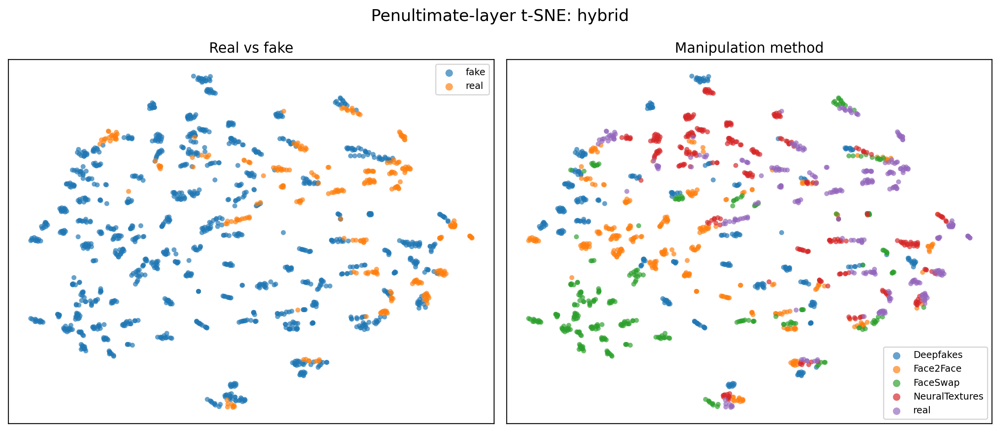

### FaceForensics++ versus Stable Diffusion domain shift

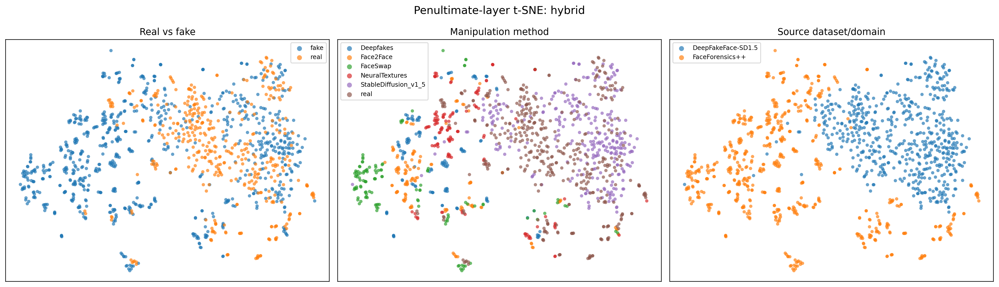

In [15]:
from src.interpret.tsne import generate_tsne

tsne_test = OUTPUT_ROOT / "figures" / "hybrid_200video_tsne_test.png"
tsne_domain = OUTPUT_ROOT / "figures" / "hybrid_200video_tsne_domain.png"

if RUN_TSNE:
    generate_tsne(
        CHECKPOINTS["hybrid"],
        [SPLIT_ROOT / "test.csv"],
        DATA_ROOT,
        tsne_test,
        source_names=["FaceForensics++"],
        device_name=DEVICE,
        batch_size=64,
        max_samples=1500,
        perplexity=35,
        seed=SEED,
    )
    generate_tsne(
        CHECKPOINTS["hybrid"],
        [SPLIT_ROOT / "test.csv", DATA_ROOT / "deepfakeface_sd15_paired.csv"],
        DATA_ROOT,
        tsne_domain,
        source_names=["FaceForensics++", "DeepFakeFace-SD1.5"],
        device_name=DEVICE,
        batch_size=64,
        max_samples=1200,
        perplexity=35,
        seed=SEED,
    )

for title, figure_path in [
    ("FaceForensics++ feature space", tsne_test),
    ("FaceForensics++ versus Stable Diffusion domain shift", tsne_domain),
]:
    if figure_path.is_file():
        display(Markdown(f"### {title}"))
        display(Image(filename=str(figure_path), width=1200))

### t-SNE interpretation

- The in-domain projection contains many small local clusters. Real and fake
  points overlap substantially, although several fake manipulation clusters
  are visible. This agrees with good-but-imperfect test AUC rather than perfect
  separability.
- Manipulation methods occupy different parts of the representation. The model
  therefore learns method-specific structure instead of one universal
  deepfake signature.
- In the combined plot, FaceForensics++ and DeepFakeFace/Stable Diffusion form
  strongly different regions. Dataset/domain separation is more obvious than
  real/fake separation.
- Stable Diffusion fake and real samples overlap inside their new domain. This
  visually explains why a detector trained on FaceForensics++ falls to an AUC
  below 0.4 on the cross-generation test.

This is qualitative evidence of domain shift, not proof that each cluster has
a single semantic meaning. t-SNE can distort global distances and should be
reported alongside the quantitative AUC results.

## 14. Grad-CAM interpretability

### meso_100video_gradcam

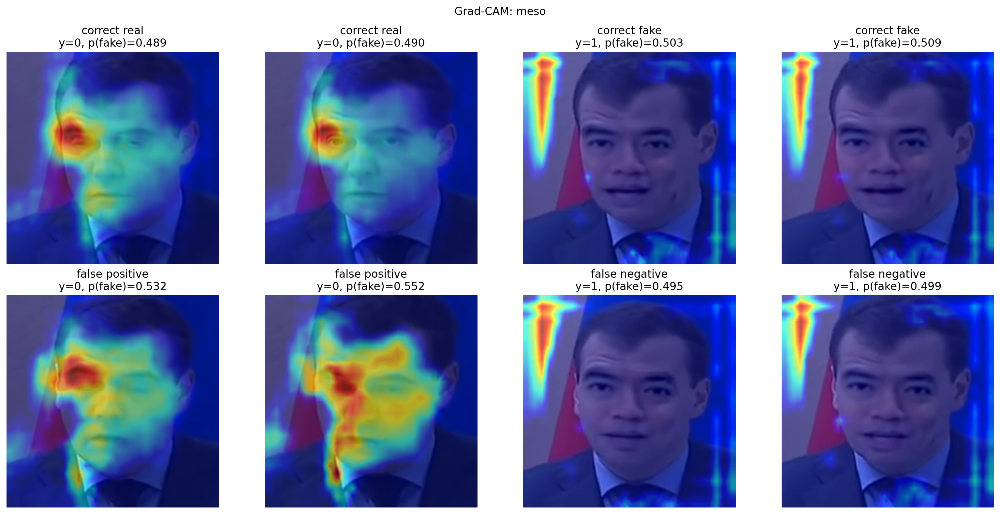

### freq_cnn_100video_gradcam

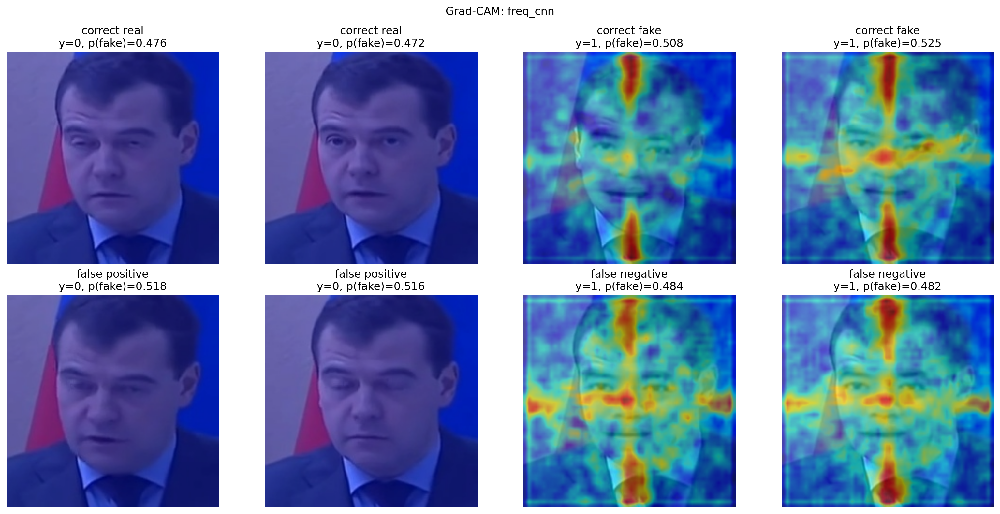

### hybrid_100video_gradcam

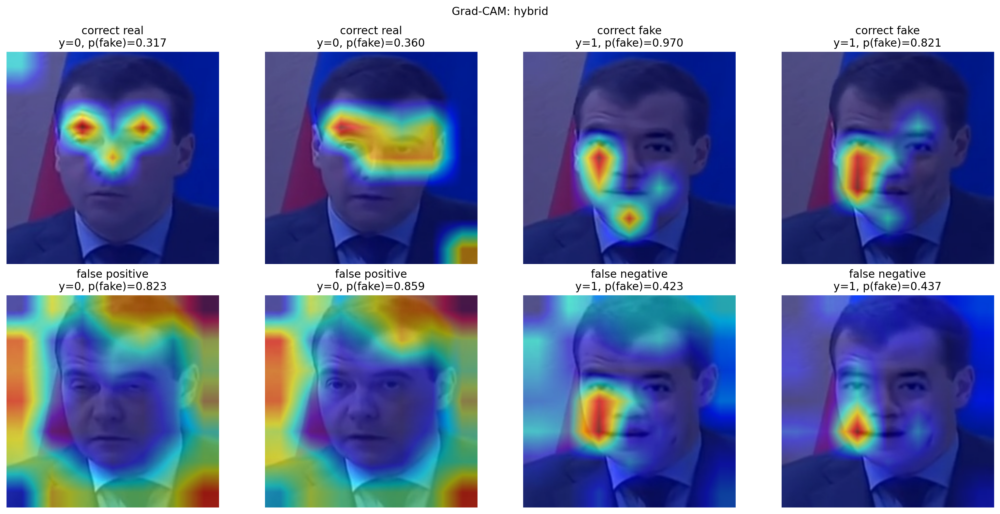

### xception_100video_corrected_gradcam

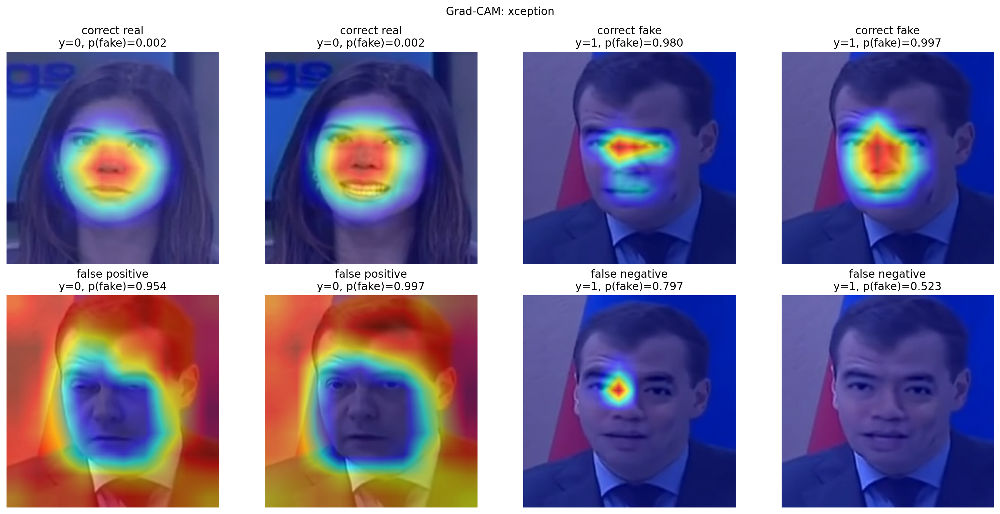

In [16]:
gradcam_files = [
    OUTPUT_ROOT / "figures" / "meso_100video_gradcam.png",
    OUTPUT_ROOT / "figures" / "freq_cnn_100video_gradcam.png",
    OUTPUT_ROOT / "figures" / "hybrid_100video_gradcam.png",
    OUTPUT_ROOT / "figures" / "xception_100video_corrected_gradcam.png",
]
for path in gradcam_files:
    if path.is_file():
        display(Markdown(f"### {path.stem}"))
        display(Image(filename=str(path), width=900))

Grad-CAM highlights the facial regions influencing correct and incorrect
decisions. It helps identify whether models use meaningful areas such as eyes,
mouth and blending boundaries, or unreliable background/compression cues.

## 15. Implementation verification

In [17]:
verification = pd.DataFrame([
    ("Frame extraction and sampling", "Complete"),
    ("MTCNN face detection and alignment", "Complete"),
    ("Identity-safe splitting", "Complete"),
    ("MesoInception", "Complete"),
    ("Corrected Xception", "Complete"),
    ("Frequency CNN", "Complete"),
    ("CoAtNet hybrid", "Complete"),
    ("Validation-calibrated ensemble", "Complete"),
    ("Per-method and video metrics", "Complete"),
    ("JPEG robustness", "Complete"),
    ("Stable Diffusion cross-generation test", "Complete"),
    ("Grad-CAM", "Complete"),
    ("Automated tests", "37 passing"),
], columns=["Component", "Status"])
display(verification)

,Component,Status
0,Frame extraction and sampling,Complete
1,MTCNN face detection and alignment,Complete
2,Identity-safe splitting,Complete
3,MesoInception,Complete
4,Corrected Xception,Complete
5,Frequency CNN,Complete
6,CoAtNet hybrid,Complete
7,Validation-calibrated ensemble,Complete
8,Per-method and video metrics,Complete
9,JPEG robustness,Complete


## 16. Conclusions

1. The final system is a complete and reproducible deepfake-detection pipeline.
2. CoAtNet is the strongest single-frame model: AUC **0.8833**, F1 **0.8607**.
3. Video aggregation is beneficial, reaching AUC approximately **0.904**.
4. The hybrid is more compression-robust than Xception, but both degrade under
   severe JPEG compression.
5. In-domain success does not transfer to Stable Diffusion faces.
6. The main contribution is therefore both the detector and the controlled
   demonstration of its generalisation limits.

The results are credible because identities are separated, thresholds and
ensemble weights are selected on validation data, and the diffusion test is
not used for tuning. The implementation is complete; remaining work concerns
report writing, presentation and optional future datasets such as Celeb-DF.

## 17. Key output files

| Output | Location |
|---|---|
| Final model comparison | `outputs/tables/model_summary_200video_cloud.csv` |
| Per-method results | `outputs/tables/per_method_summary_200video_cloud.csv` |
| Compression results | `outputs/tables/compression_200video_cloud.csv` |
| Cross-generation result | `outputs/tables/hybrid_200video_cloud_cross_generation.json` |
| Frame ensemble | `outputs/tables/ensemble_200video_cloud_frame.json` |
| Video ensemble | `outputs/tables/ensemble_200video_cloud_video.json` |
| Best hybrid checkpoint | `outputs/modal_downloads/hybrid_200video_full_best.pt` |
| Best Xception checkpoint | `outputs/modal_downloads/xception_200video_full_best.pt` |
| Figures | `outputs/figures/` |